# ☕ Coffee Shop Sales Analysis

**Author:** Bhoomi Katarmal  
**Dataset:** `Coffee_Shop_Sales.csv`  
**Description:** End-to-end data analytics project — data loading, cleaning, EDA, sales trends,
product performance, store comparison, peak-hour behaviour, and business recommendations.

---

## 📋 Table of Contents
1. [Load & Inspect Dataset](#1-load--inspect-dataset)
2. [Data Quality Check](#2-data-quality-check)
3. [Feature Engineering — Total Sales](#3-feature-engineering--total-sales)
4. [Group & Summarise](#4-group--summarise)
5. [Sales Trend Analysis](#5-sales-trend-analysis)
6. [Product Category & Type Analysis](#6-product-category--type-analysis)
7. [Store Location Performance](#7-store-location-performance)
8. [Peak Hours & Day-of-Week Analysis](#8-peak-hours--day-of-week-analysis)
9. [Revenue Insights & MoM Growth](#9-revenue-insights--mom-growth)
10. [Business Decisions & Recommendations](#10-business-decisions--recommendations)
11. [Streamlit Interactive Dashboard](#11-streamlit-interactive-dashboard)

---
## 1. Load & Inspect Dataset

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize']    = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('✅ Libraries imported.')

✅ Libraries imported.


In [2]:
# ── 1. Collect & Load Dataset ─────────────────────────────────────────────────
df = pd.read_csv('Coffee_Shop_Sales.csv')

print(f'Shape : {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head(10)

Shape : 149,116 rows  ×  10 columns
Columns: ['transaction_id', 'transaction_date', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type']


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type
0,1,1/1/23,7:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee
1,2,1/1/23,7:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea
2,3,1/1/23,7:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate
3,4,1/1/23,7:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee
4,5,1/1/23,7:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea
5,6,1/1/23,7:22:41,1,5,Lower Manhattan,77,3.00,Bakery,Scone
6,7,1/1/23,7:25:49,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee
7,8,1/1/23,7:33:34,2,5,Lower Manhattan,28,2.00,Coffee,Gourmet brewed coffee
8,9,1/1/23,7:39:13,1,5,Lower Manhattan,39,4.25,Coffee,Barista Espresso
9,10,1/1/23,7:39:34,2,5,Lower Manhattan,58,3.50,Drinking Chocolate,Hot chocolate


In [3]:
# Column data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_date  149116 non-null  str    
 2   transaction_time  149116 non-null  str    
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  str    
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  str    
 9   product_type      149116 non-null  str    
dtypes: float64(1), int64(4), str(5)
memory usage: 18.1 MB


In [4]:
# Statistical summary
df.describe()

,transaction_id,transaction_qty,store_id,product_id,unit_price
count,149116.00,149116.00,149116.00,149116.00,149116.00
mean,74737.37,1.44,5.34,47.92,3.38
std,43153.60,0.54,2.07,17.93,2.66
min,1.00,1.00,3.00,1.00,0.80
25%,37335.75,1.00,3.00,33.00,2.50
50%,74727.50,1.00,5.00,47.00,3.00
75%,112094.25,2.00,8.00,60.00,3.75
max,149456.00,8.00,8.00,87.00,45.00


---
## 2. Data Quality Check

In [5]:
# ── 2a. Missing values ────────────────────────────────────────────────────────
missing = df.isnull().sum()
print('Missing values per column:')
print(missing.to_string())
print(f'\nTotal missing cells : {missing.sum()}')
if missing.sum() == 0:
    print('✅ No missing values found.')

Missing values per column:
transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0

Total missing cells : 0
✅ No missing values found.


In [6]:
# ── 2b. Duplicate rows ────────────────────────────────────────────────────────
dupes = df.duplicated().sum()
print(f'Duplicate rows : {dupes}')
if dupes == 0:
    print('✅ No duplicate rows found.')

Duplicate rows : 0
✅ No duplicate rows found.


In [7]:
# ── 2c. Incorrect / negative numeric values ────────────────────────────────────
neg_qty   = (df['transaction_qty'] <= 0).sum()
neg_price = (df['unit_price']      <= 0).sum()
print(f'Rows with quantity <= 0 : {neg_qty}')
print(f'Rows with unit_price <= 0 : {neg_price}')

print('\nUnique store locations :', df['store_location'].unique())
print('Unique product categories:', df['product_category'].unique())
print('\n✅ Data quality check complete — dataset is clean.')

Rows with quantity <= 0 : 0
Rows with unit_price <= 0 : 0



Unique store locations : <ArrowStringArray>
['Lower Manhattan', 'Hell's Kitchen', 'Astoria']
Length: 3, dtype: str
Unique product categories: <ArrowStringArray>
[            'Coffee',                'Tea', 'Drinking Chocolate',
             'Bakery',           'Flavours',          'Loose Tea',
       'Coffee beans', 'Packaged Chocolate',            'Branded']
Length: 9, dtype: str

✅ Data quality check complete — dataset is clean.


---
## 3. Feature Engineering — Total Sales

In [8]:
# ── 3. Total Sales = Quantity × Unit Price ────────────────────────────────────
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='%m/%d/%y')
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.time

df['total_sales']  = (df['transaction_qty'] * df['unit_price']).round(2)  # = revenue
df['month']        = df['transaction_date'].dt.month
df['month_name']   = df['transaction_date'].dt.strftime('%b')
df['day_name']     = df['transaction_date'].dt.strftime('%a')
df['day_of_week']  = df['transaction_date'].dt.dayofweek
df['hour']         = df['transaction_time'].apply(lambda t: t.hour)

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
day_order   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)
df['day_name']   = pd.Categorical(df['day_name'],   categories=day_order,   ordered=True)

print('✅ Feature engineering complete.')
print(f"Date range: {df['transaction_date'].min().date()}  →  {df['transaction_date'].max().date()}")
df[['transaction_date','transaction_time','transaction_qty','unit_price','total_sales',
    'month_name','day_name','hour']].head(10)

✅ Feature engineering complete.
Date range: 2023-01-01  →  2023-06-30


,transaction_date,transaction_time,transaction_qty,unit_price,total_sales,month_name,day_name,hour
0,2023-01-01,07:06:11,2,3.00,6.00,Jan,Sun,7
1,2023-01-01,07:08:56,2,3.10,6.20,Jan,Sun,7
2,2023-01-01,07:14:04,2,4.50,9.00,Jan,Sun,7
3,2023-01-01,07:20:24,1,2.00,2.00,Jan,Sun,7
4,2023-01-01,07:22:41,2,3.10,6.20,Jan,Sun,7
5,2023-01-01,07:22:41,1,3.00,3.00,Jan,Sun,7
6,2023-01-01,07:25:49,1,2.00,2.00,Jan,Sun,7
7,2023-01-01,07:33:34,2,2.00,4.00,Jan,Sun,7
8,2023-01-01,07:39:13,1,4.25,4.25,Jan,Sun,7
9,2023-01-01,07:39:34,2,3.50,7.00,Jan,Sun,7


---
## 4. Group & Summarise

In [9]:
# ── High-level KPIs ───────────────────────────────────────────────────────────
print('=' * 54)
print('       COFFEE SHOP — HIGH-LEVEL KPIs')
print('=' * 54)
print(f"  Total Transactions    : {len(df):>12,}")
print(f"  Total Revenue         : ${df['total_sales'].sum():>12,.2f}")
print(f"  Avg Transaction Value : ${df['total_sales'].mean():>12.2f}")
print(f"  Total Units Sold      : {df['transaction_qty'].sum():>12,}")
print(f"  Unique Product Types  : {df['product_type'].nunique():>12}")
print(f"  Product Categories    : {df['product_category'].nunique():>12}")
print(f"  Store Locations       : {df['store_location'].nunique():>12}")
print('=' * 54)

       COFFEE SHOP — HIGH-LEVEL KPIs
  Total Transactions    :      149,116
  Total Revenue         : $  698,812.33
  Avg Transaction Value : $        4.69
  Total Units Sold      :      214,470
  Unique Product Types  :           29
  Product Categories    :            9
  Store Locations       :            3


In [10]:
# ── Revenue by product category ───────────────────────────────────────────────
cat_summary = df.groupby('product_category').agg(
    Total_Revenue  =('total_sales',     'sum'),
    Transactions   =('transaction_id',  'count'),
    Units_Sold     =('transaction_qty', 'sum'),
    Avg_Unit_Price =('unit_price',      'mean')
).sort_values('Total_Revenue', ascending=False).reset_index()
cat_summary['Revenue_Share_%'] = (cat_summary['Total_Revenue'] / cat_summary['Total_Revenue'].sum() * 100).round(1)
print('Revenue by Product Category:')
cat_summary

Revenue by Product Category:


,product_category,Total_Revenue,Transactions,Units_Sold,Avg_Unit_Price,Revenue_Share_%
0,Coffee,269952.45,58416,89250,3.02,38.60
1,Tea,196405.95,45449,69737,2.82,28.10
2,Bakery,82315.64,22796,23214,3.55,11.80
3,Drinking Chocolate,72416.00,11468,17457,4.15,10.40
4,Coffee beans,40085.25,1753,1828,21.02,5.70
5,Branded,13607.00,747,776,17.72,1.90
6,Loose Tea,11213.60,1210,1210,9.27,1.60
7,Flavours,8408.80,6790,10511,0.80,1.20
8,Packaged Chocolate,4407.64,487,487,9.05,0.60


In [11]:
# ── Revenue by store ──────────────────────────────────────────────────────────
store_summary = df.groupby('store_location').agg(
    Total_Revenue      =('total_sales',     'sum'),
    Total_Transactions =('transaction_id',  'count'),
    Total_Units_Sold   =('transaction_qty', 'sum'),
    Avg_Order_Value    =('total_sales',     'mean')
).reset_index()
store_summary['Revenue_Share_%'] = (store_summary['Total_Revenue'] / store_summary['Total_Revenue'].sum() * 100).round(1)
print('Revenue by Store Location:')
store_summary

Revenue by Store Location:


,store_location,Total_Revenue,Total_Transactions,Total_Units_Sold,Avg_Order_Value,Revenue_Share_%
0,Astoria,232243.91,50599,70991,4.59,33.20
1,Hell's Kitchen,236511.17,50735,71737,4.66,33.80
2,Lower Manhattan,230057.25,47782,71742,4.81,32.90


In [12]:
# ── Monthly summary ───────────────────────────────────────────────────────────
monthly = df.groupby('month_name', observed=True).agg(
    Revenue      =('total_sales',    'sum'),
    Transactions =('transaction_id', 'count'),
    Units_Sold   =('transaction_qty','sum')
).reset_index()
monthly['MoM_Growth_%'] = monthly['Revenue'].pct_change().mul(100).round(2)
print('Monthly Summary:')
monthly

Monthly Summary:


,month_name,Revenue,Transactions,Units_Sold,MoM_Growth_%
0,Jan,81677.74,17314,24870,NaN
1,Feb,76145.19,16359,23550,-6.77
2,Mar,98834.68,21229,30406,29.80
3,Apr,118941.08,25335,36469,20.34
4,May,156727.76,33527,48233,31.77
5,Jun,166485.88,35352,50942,6.23


---
## 5. Sales Trend Analysis

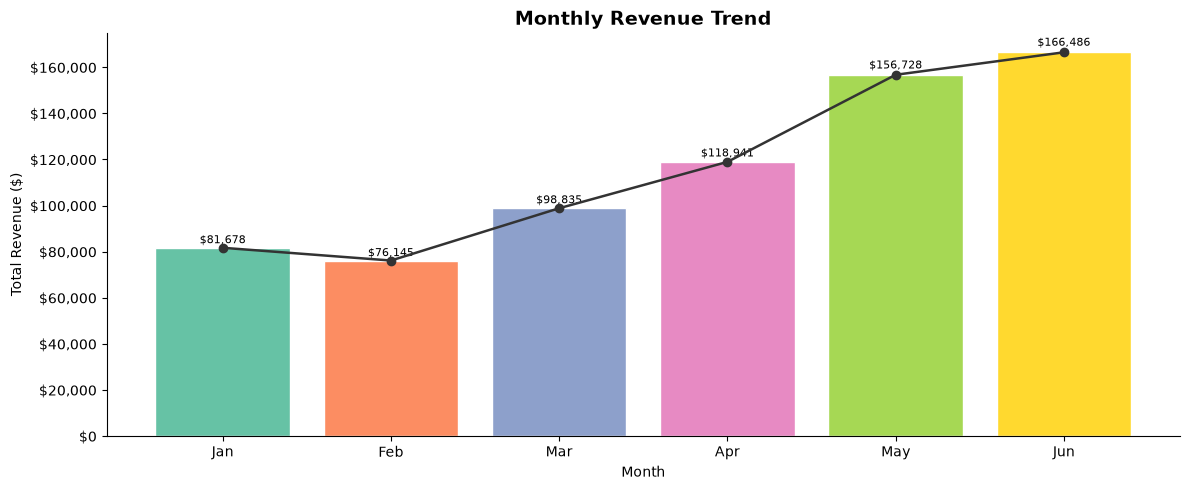

In [13]:
# ── Monthly revenue bar + trend line ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
colors = sns.color_palette('Set2', len(monthly))
bars = ax.bar(monthly['month_name'], monthly['Revenue'], color=colors, edgecolor='white')
ax.plot(monthly['month_name'], monthly['Revenue'],
        marker='o', color='#333', linewidth=1.8, markersize=6, zorder=5)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+bar.get_height()*0.01,
            f"${bar.get_height():,.0f}", ha='center', va='bottom', fontsize=8)
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Total Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout(); plt.show()

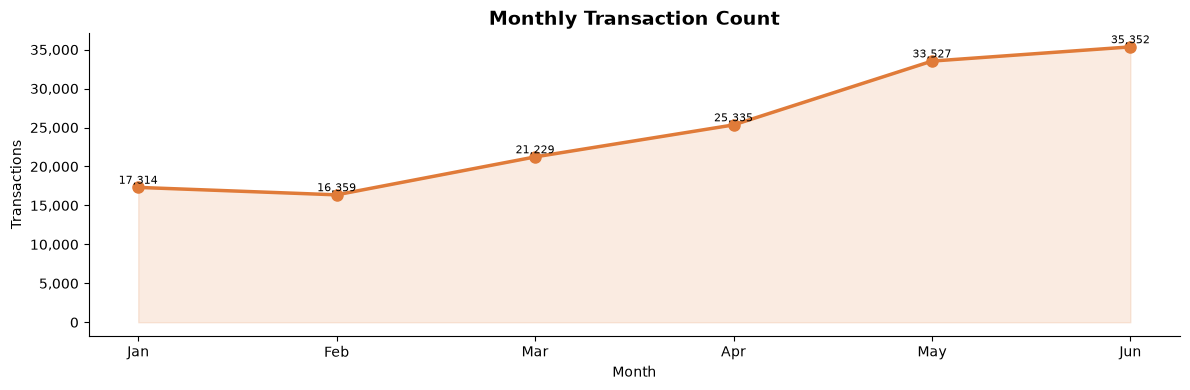

In [14]:
# ── Monthly transaction count ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['month_name'].astype(str), monthly['Transactions'],
        marker='o', color='#e07b39', linewidth=2.5, markersize=8)
ax.fill_between(range(len(monthly)), monthly['Transactions'], alpha=0.15, color='#e07b39')
for i, row in monthly.iterrows():
    ax.text(i, row['Transactions']+120, f"{row['Transactions']:,}",
            ha='center', va='bottom', fontsize=8)
ax.set_xticks(range(len(monthly))); ax.set_xticklabels(monthly['month_name'])
ax.set_title('Monthly Transaction Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout(); plt.show()

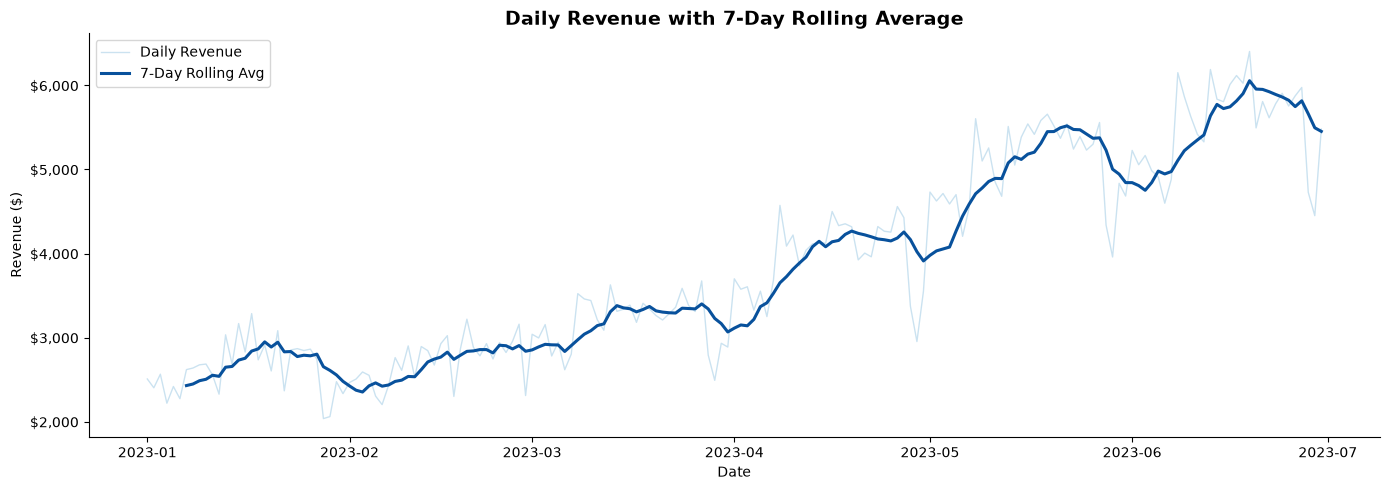

In [15]:
# ── Daily revenue + 7-day rolling average ────────────────────────────────────
daily = df.groupby('transaction_date')['total_sales'].sum().reset_index()
daily['rolling_7d'] = daily['total_sales'].rolling(7).mean()
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily['transaction_date'], daily['total_sales'],
        alpha=0.35, color='#6baed6', linewidth=1, label='Daily Revenue')
ax.plot(daily['transaction_date'], daily['rolling_7d'],
        color='#08519c', linewidth=2.2, label='7-Day Rolling Avg')
ax.set_title('Daily Revenue with 7-Day Rolling Average', fontsize=14, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend(); plt.tight_layout(); plt.show()

---
## 6. Product Category & Type Analysis

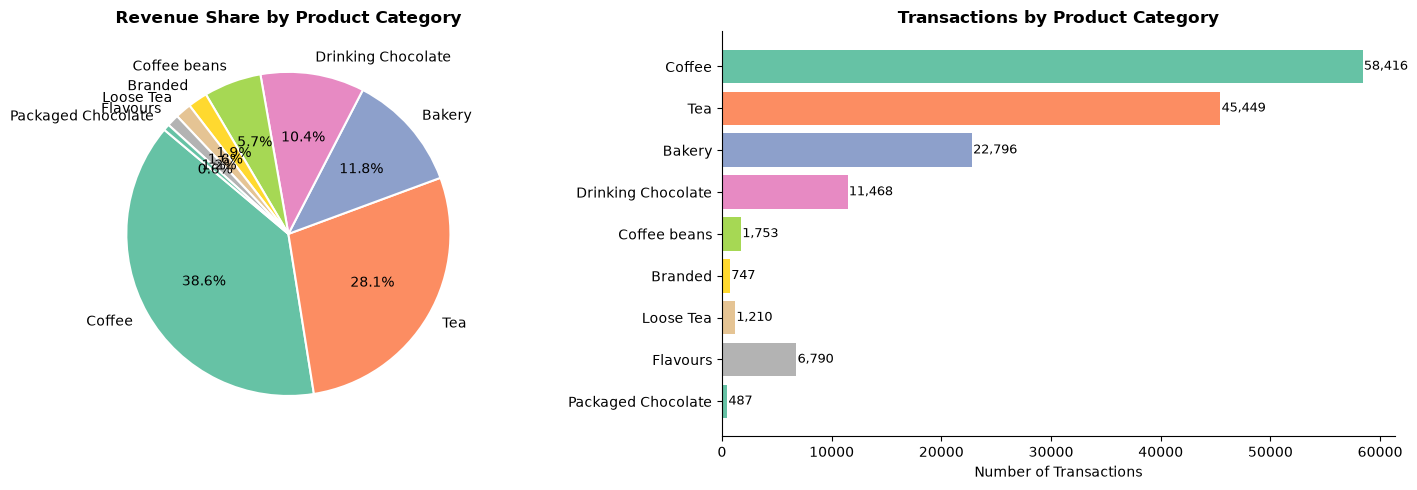

In [16]:
# ── Revenue share pie + transaction bar ──────────────────────────────────────
pal = sns.color_palette('Set2', len(cat_summary))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].pie(cat_summary['Total_Revenue'], labels=cat_summary['product_category'],
            autopct='%1.1f%%', startangle=140, colors=pal,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Revenue Share by Product Category', fontsize=12, fontweight='bold')
bars = axes[1].barh(cat_summary['product_category'][::-1],
                    cat_summary['Transactions'][::-1], color=pal[::-1])
axes[1].set_title('Transactions by Product Category', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Transactions')
for bar in bars:
    axes[1].text(bar.get_width()+100, bar.get_y()+bar.get_height()/2,
                 f'{bar.get_width():,.0f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

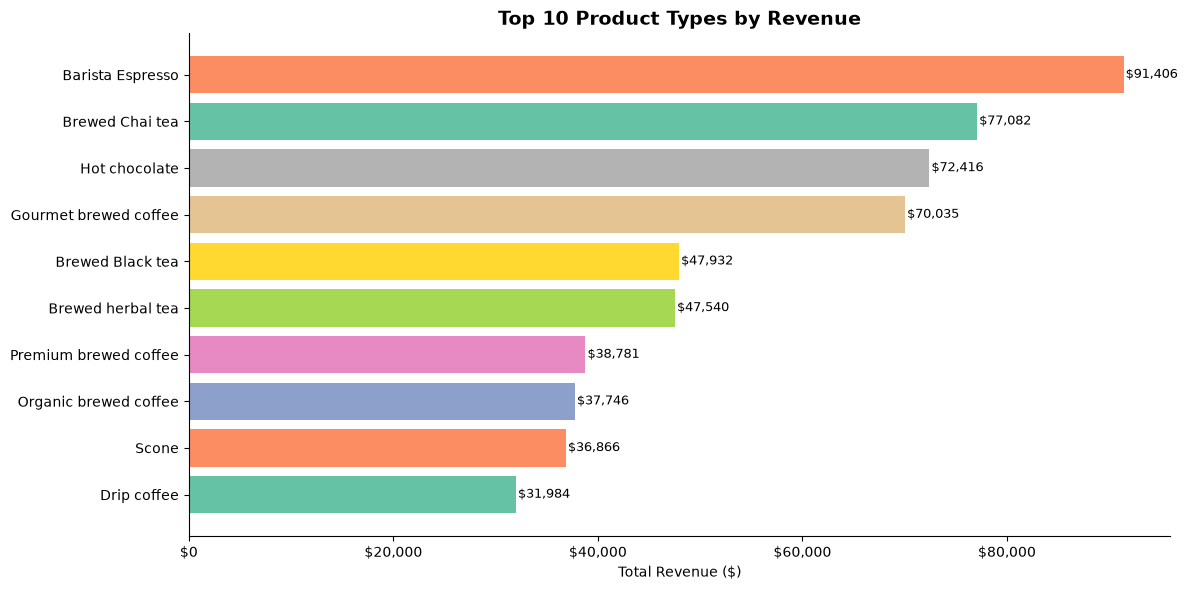

In [17]:
# ── Top 10 product types by revenue ──────────────────────────────────────────
top10_rev = (df.groupby('product_type')['total_sales']
             .sum().sort_values(ascending=False).head(10).reset_index())
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_rev['product_type'][::-1], top10_rev['total_sales'][::-1],
               color=sns.color_palette('Set2', 10))
for bar in bars:
    ax.text(bar.get_width()+200, bar.get_y()+bar.get_height()/2,
            f"${bar.get_width():,.0f}", va='center', fontsize=9)
ax.set_title('Top 10 Product Types by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout(); plt.show()

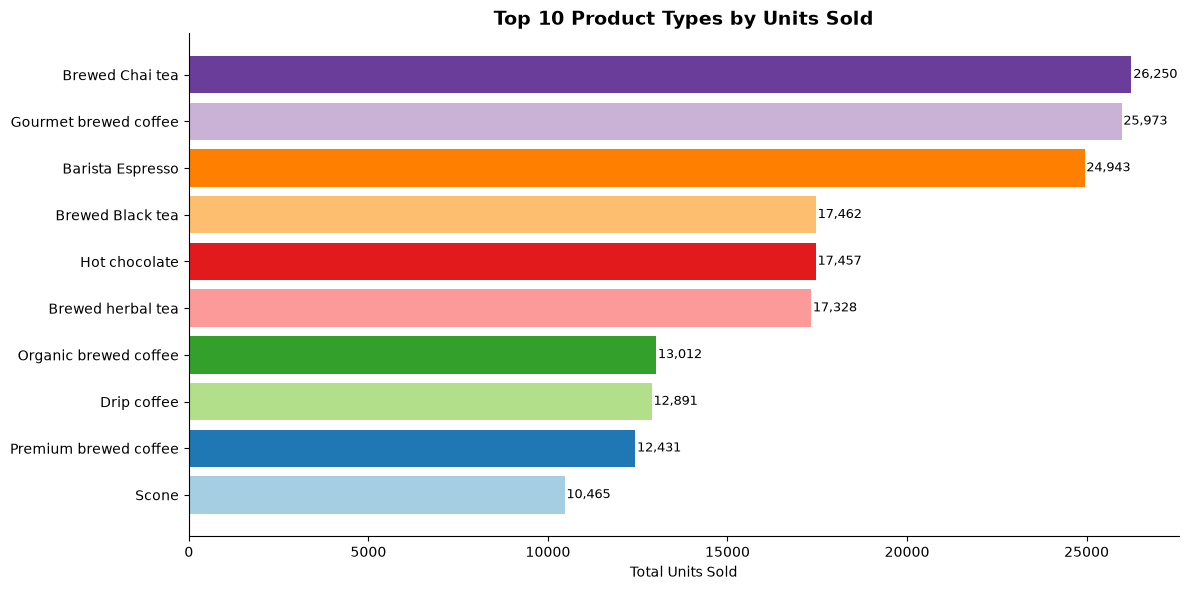

In [18]:
# ── Top 10 product types by units sold ───────────────────────────────────────
top10_qty = (df.groupby('product_type')['transaction_qty']
             .sum().sort_values(ascending=False).head(10).reset_index())
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_qty['product_type'][::-1], top10_qty['transaction_qty'][::-1],
               color=sns.color_palette('Paired', 10))
for bar in bars:
    ax.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2,
            f"{bar.get_width():,.0f}", va='center', fontsize=9)
ax.set_title('Top 10 Product Types by Units Sold', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Units Sold')
plt.tight_layout(); plt.show()

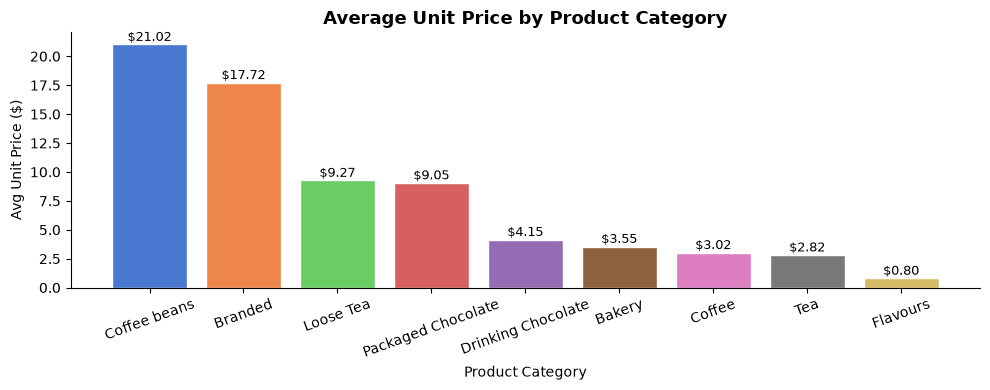

In [19]:
# ── Average unit price by category ───────────────────────────────────────────
avg_price = (df.groupby('product_category')['unit_price']
             .mean().sort_values(ascending=False).reset_index())
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(avg_price['product_category'], avg_price['unit_price'],
              color=sns.color_palette('muted', len(avg_price)), edgecolor='white')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f"${bar.get_height():.2f}", ha='center', va='bottom', fontsize=9)
ax.set_title('Average Unit Price by Product Category', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Unit Price ($)'); ax.set_xlabel('Product Category')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

---
## 7. Store Location Performance

 store_location  Total_Revenue  Total_Transactions  Total_Units_Sold  Avg_Order_Value  Revenue_Share_%
        Astoria      232243.91               50599             70991             4.59            33.20
 Hell's Kitchen      236511.17               50735             71737             4.66            33.80
Lower Manhattan      230057.25               47782             71742             4.81            32.90


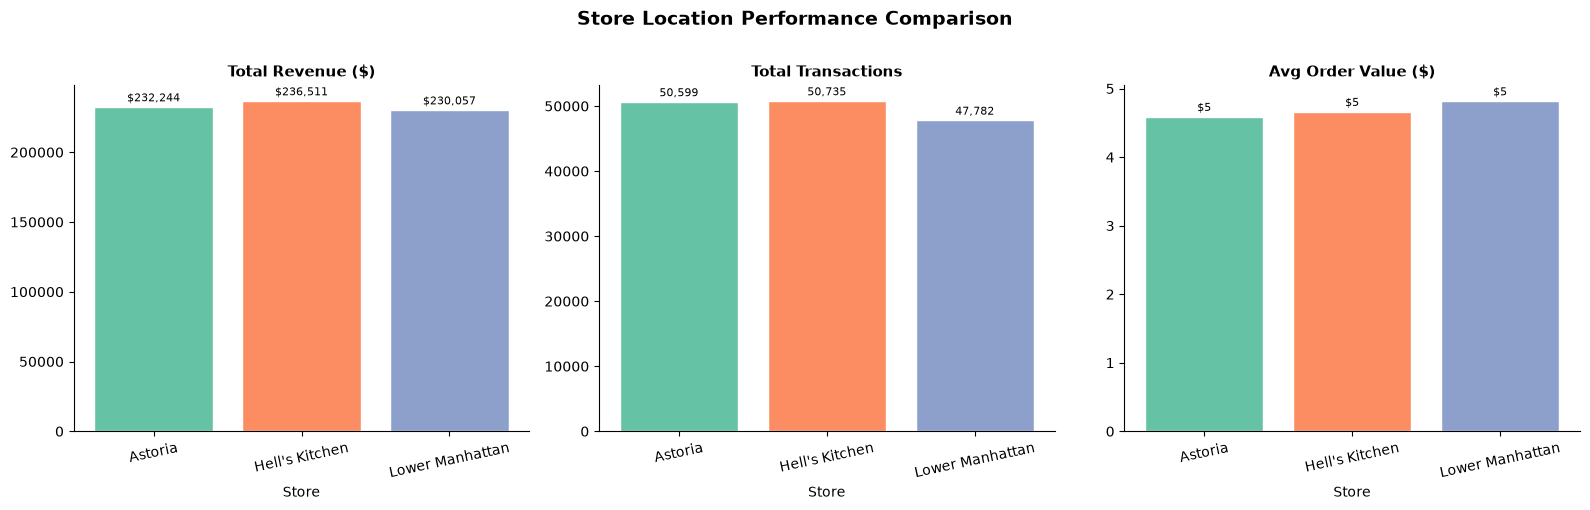

In [20]:
# ── Store KPI comparison ──────────────────────────────────────────────────────
print(store_summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['Total_Revenue','Total_Transactions','Avg_Order_Value']
titles  = ['Total Revenue ($)','Total Transactions','Avg Order Value ($)']
pal2 = sns.color_palette('Set2', len(store_summary))
for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(store_summary['store_location'], store_summary[metric],
                  color=pal2, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Store'); ax.tick_params(axis='x', rotation=12)
    for bar in bars:
        v = bar.get_height()
        lbl = f'${v:,.0f}' if '$' in title else f'{v:,.0f}'
        ax.text(bar.get_x()+bar.get_width()/2, v+v*0.01, lbl,
                ha='center', va='bottom', fontsize=8)
plt.suptitle('Store Location Performance Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

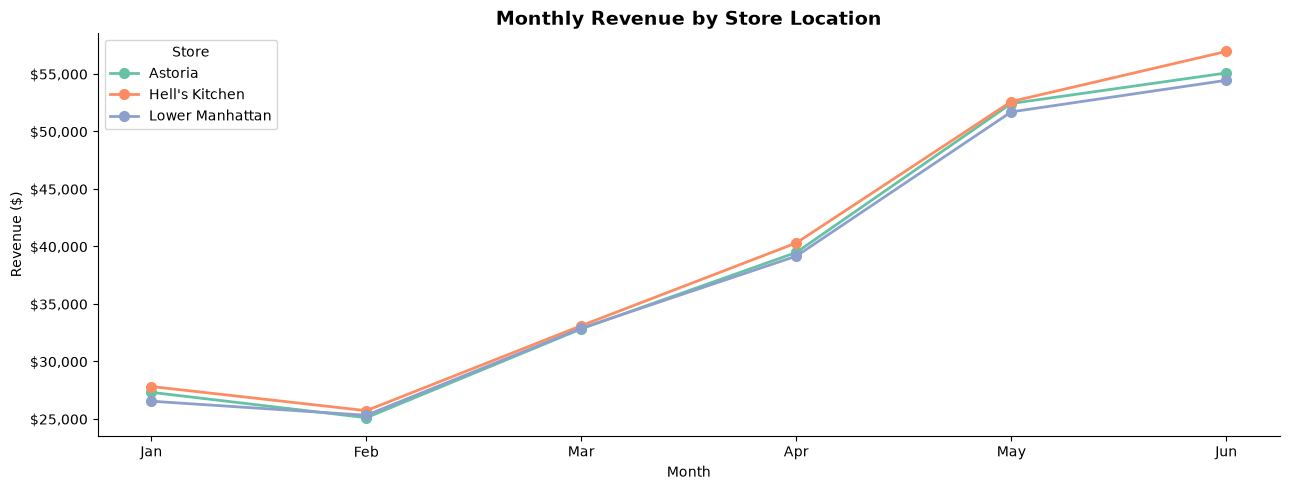

In [21]:
# ── Monthly revenue by store ──────────────────────────────────────────────────
store_monthly = (df.groupby(['month_name','store_location'], observed=True)['total_sales']
                 .sum().reset_index())
fig, ax = plt.subplots(figsize=(13, 5))
for store, grp in store_monthly.groupby('store_location'):
    ax.plot(grp['month_name'].astype(str), grp['total_sales'],
            marker='o', linewidth=2, markersize=7, label=store)
ax.set_title('Monthly Revenue by Store Location', fontsize=14, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend(title='Store'); plt.tight_layout(); plt.show()

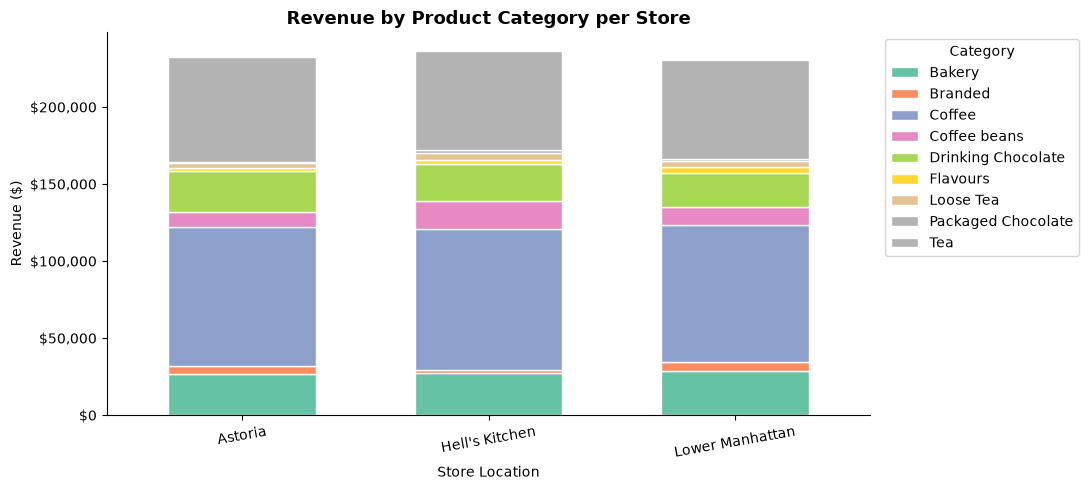

In [22]:
# ── Stacked bar — category revenue per store ─────────────────────────────────
store_cat = (df.groupby(['store_location','product_category'])['total_sales']
             .sum().unstack(fill_value=0))
store_cat.plot(kind='bar', stacked=True, figsize=(11,5),
               colormap='Set2', edgecolor='white', width=0.6)
plt.title('Revenue by Product Category per Store', fontsize=13, fontweight='bold')
plt.xlabel('Store Location'); plt.ylabel('Revenue ($)')
plt.xticks(rotation=10)
plt.legend(title='Category', bbox_to_anchor=(1.01,1), loc='upper left')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout(); plt.show()

---
## 8. Peak Hours & Day-of-Week Analysis

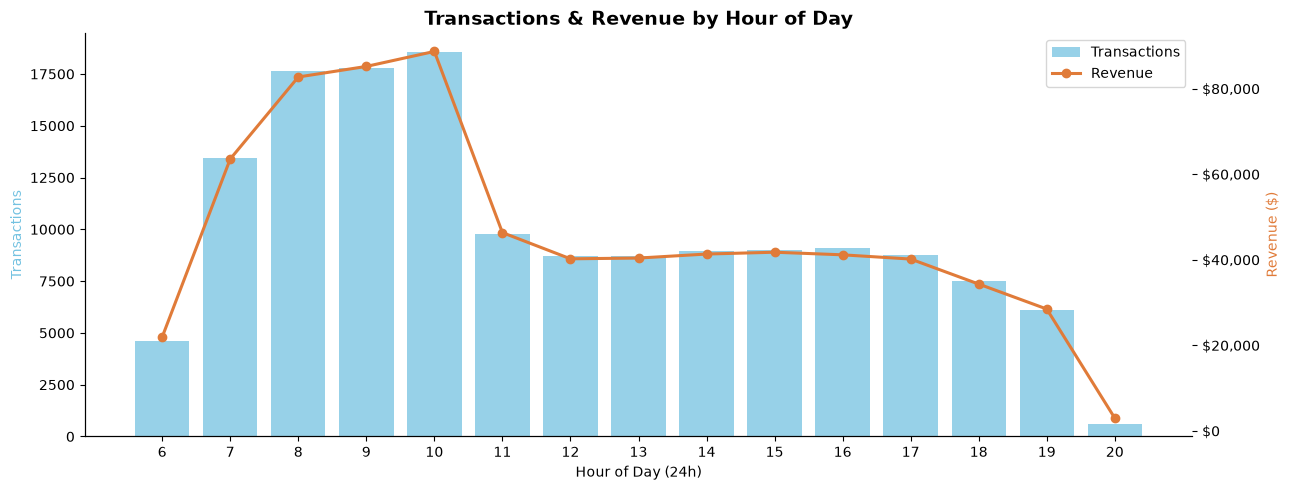

In [23]:
# ── Transactions & revenue by hour (dual-axis) ────────────────────────────────
hourly = df.groupby('hour').agg(
    transactions=('transaction_id','count'),
    revenue     =('total_sales','sum')
).reset_index()
fig, ax1 = plt.subplots(figsize=(13,5))
ax2 = ax1.twinx()
ax1.bar(hourly['hour'], hourly['transactions'], color='#74c2e1', alpha=0.75, label='Transactions')
ax2.plot(hourly['hour'], hourly['revenue'], color='#e07b39', marker='o',
         linewidth=2.2, markersize=6, label='Revenue')
ax1.set_title('Transactions & Revenue by Hour of Day', fontsize=14, fontweight='bold')
ax1.set_xlabel('Hour of Day (24h)')
ax1.set_ylabel('Transactions', color='#74c2e1')
ax2.set_ylabel('Revenue ($)', color='#e07b39')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax1.set_xticks(hourly['hour'])
h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper right')
plt.tight_layout(); plt.show()

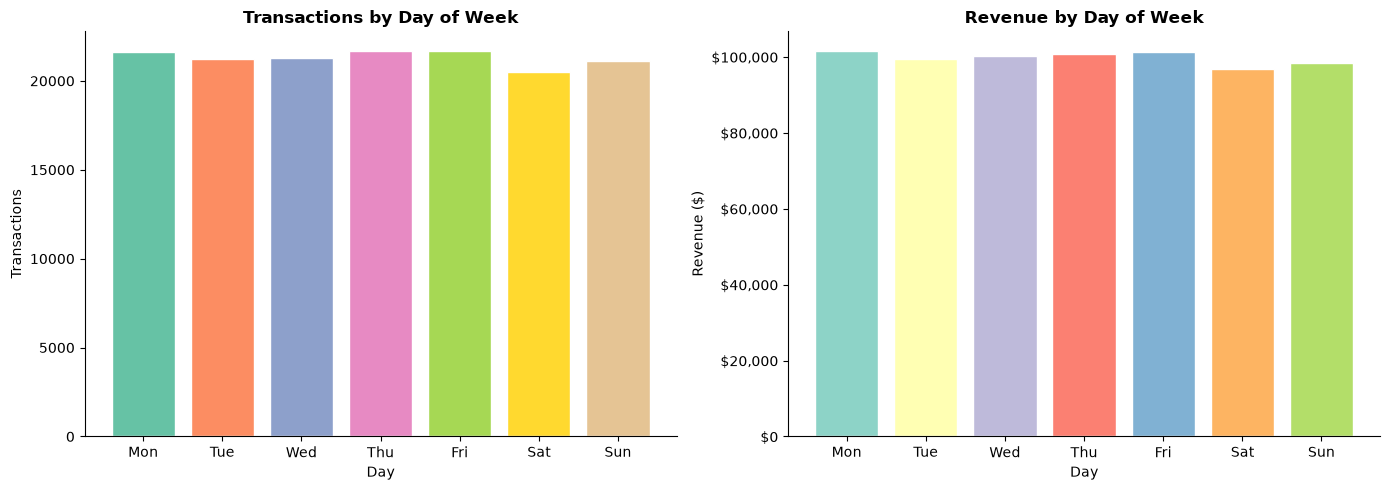

In [24]:
# ── Transactions & revenue by day of week ─────────────────────────────────────
dow = (df.groupby('day_name', observed=True)
       .agg(transactions=('transaction_id','count'), revenue=('total_sales','sum'))
       .reset_index())
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].bar(dow['day_name'], dow['transactions'],
            color=sns.color_palette('Set2',7), edgecolor='white')
axes[0].set_title('Transactions by Day of Week', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Day'); axes[0].set_ylabel('Transactions')
axes[1].bar(dow['day_name'], dow['revenue'],
            color=sns.color_palette('Set3',7), edgecolor='white')
axes[1].set_title('Revenue by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout(); plt.show()

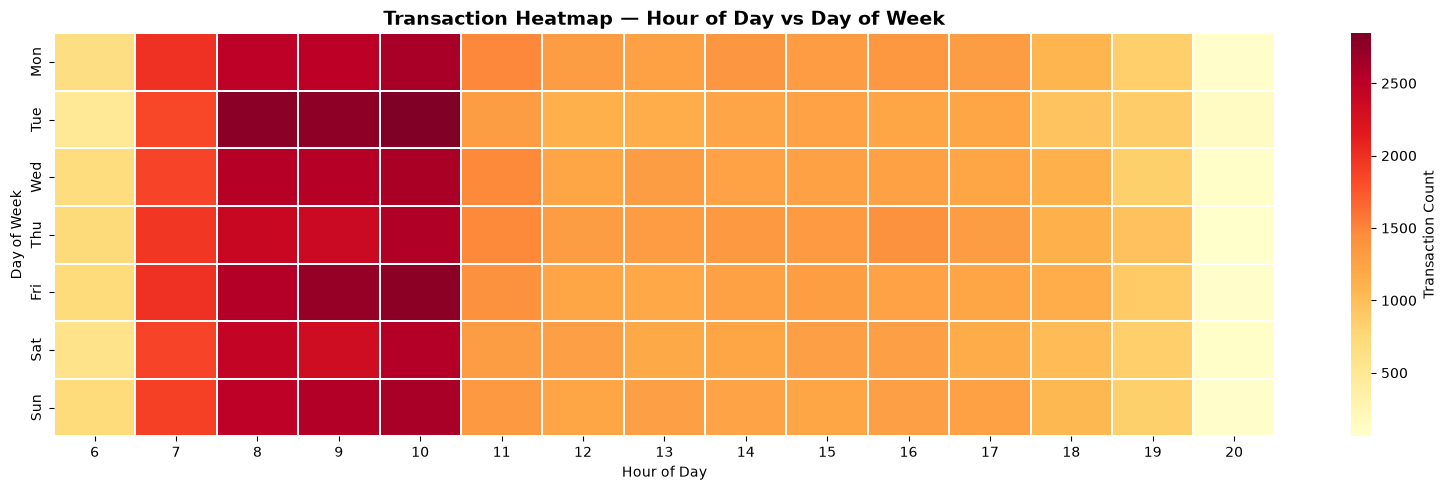

In [25]:
# ── Heatmap: Day of Week × Hour ───────────────────────────────────────────────
hm = (df.groupby(['day_name','hour'], observed=True)['transaction_id']
      .count().unstack(fill_value=0))
fig, ax = plt.subplots(figsize=(16,5))
sns.heatmap(hm, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label':'Transaction Count'}, ax=ax)
ax.set_title('Transaction Heatmap — Hour of Day vs Day of Week',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Day of Week')
plt.tight_layout(); plt.show()

---
## 9. Revenue Insights & MoM Growth

Month-over-Month Revenue Growth:
month_name   Revenue  MoM_Growth_%
       Jan  81677.74           NaN
       Feb  76145.19         -6.77
       Mar  98834.68         29.80
       Apr 118941.08         20.34
       May 156727.76         31.77
       Jun 166485.88          6.23


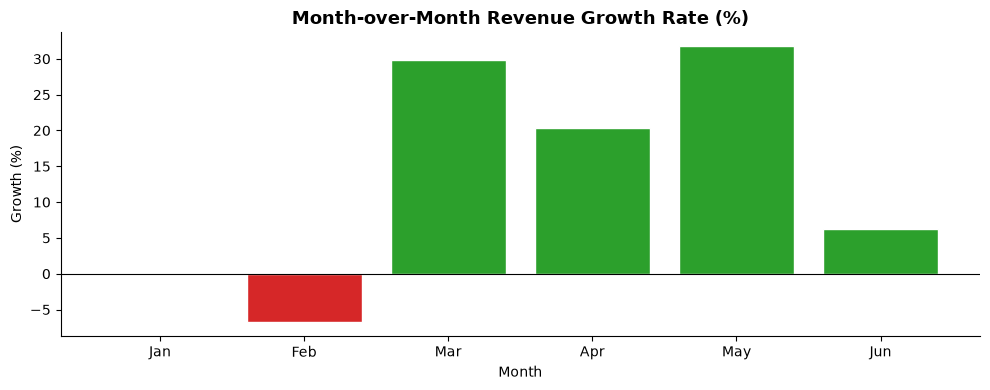

In [26]:
# ── Month-over-Month growth bar ───────────────────────────────────────────────
print('Month-over-Month Revenue Growth:')
print(monthly[['month_name','Revenue','MoM_Growth_%']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10,4))
bar_colors = ['#2ca02c' if (v >= 0 or pd.isna(v)) else '#d62728'
              for v in monthly['MoM_Growth_%']]
ax.bar(monthly['month_name'].astype(str), monthly['MoM_Growth_%'].fillna(0),
       color=bar_colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Month-over-Month Revenue Growth Rate (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Growth (%)')
plt.tight_layout(); plt.show()

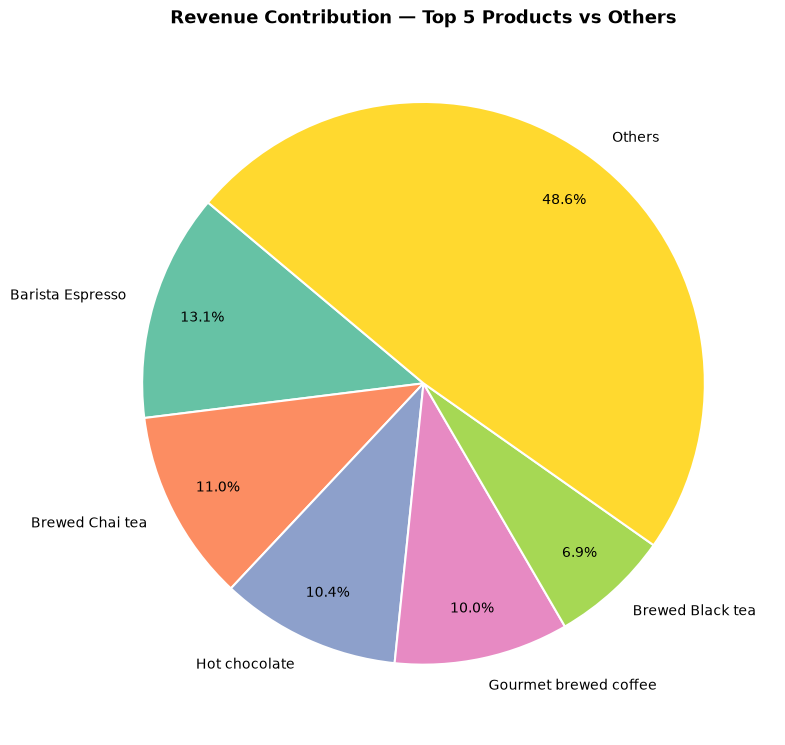

In [27]:
# ── Top 5 products vs Others — revenue pie ────────────────────────────────────
prod_rev = df.groupby('product_type')['total_sales'].sum().sort_values(ascending=False)
top5   = prod_rev.head(5)
others = pd.Series({'Others': prod_rev.iloc[5:].sum()})
pie_data = pd.concat([top5, others])
fig, ax = plt.subplots(figsize=(8,8))
ax.pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%', startangle=140,
       colors=sns.color_palette('Set2', len(pie_data)),
       wedgeprops={'edgecolor':'white','linewidth':1.5}, pctdistance=0.82)
ax.set_title('Revenue Contribution — Top 5 Products vs Others',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

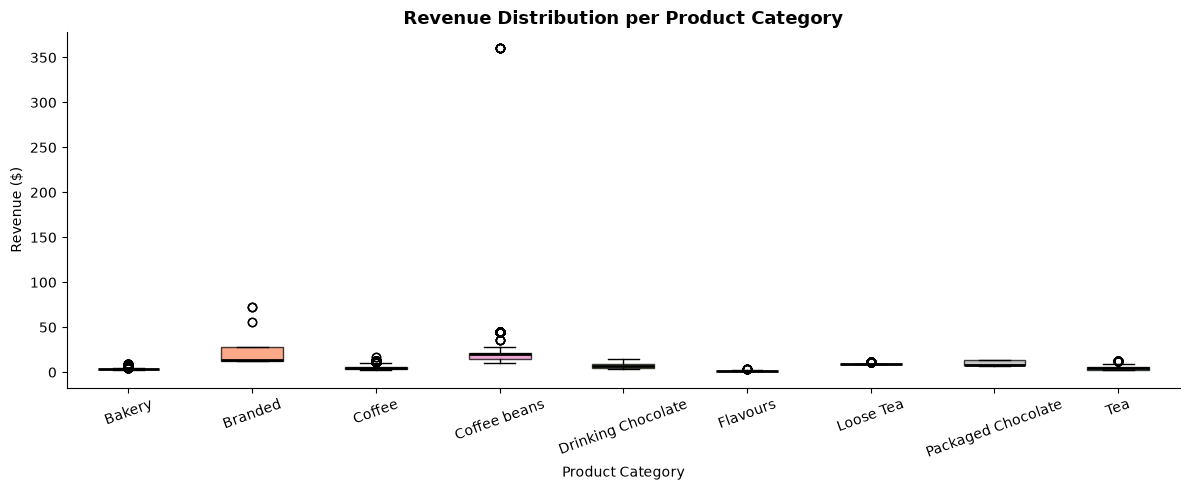

In [28]:
# ── Revenue distribution boxplot by category ─────────────────────────────────
categories = sorted(df['product_category'].unique())
plot_data  = [df[df['product_category']==c]['total_sales'].values for c in categories]
fig, ax = plt.subplots(figsize=(12,5))
bp = ax.boxplot(plot_data, tick_labels=categories, patch_artist=True,
                medianprops={'color':'black','linewidth':2})
for patch, color in zip(bp['boxes'], sns.color_palette('Set2', len(categories))):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_title('Revenue Distribution per Product Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Product Category'); ax.set_ylabel('Revenue ($)')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

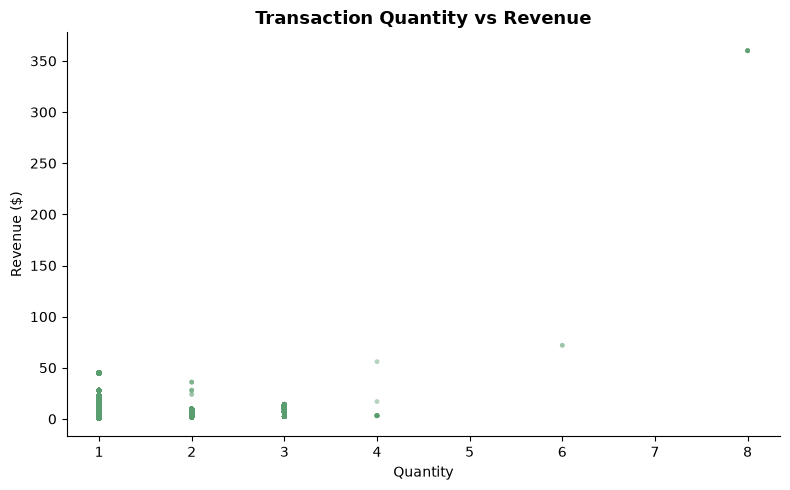

Pearson Correlation (Qty vs Revenue): 0.3562


In [29]:
# ── Quantity vs Revenue scatter ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(df['transaction_qty'], df['total_sales'],
           alpha=0.25, color='#5a9e6f', edgecolors='none', s=12)
ax.set_title('Transaction Quantity vs Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Quantity'); ax.set_ylabel('Revenue ($)')
plt.tight_layout(); plt.show()
corr = df['transaction_qty'].corr(df['total_sales'])
print(f'Pearson Correlation (Qty vs Revenue): {corr:.4f}')

---
## 10. Business Decisions & Recommendations

In [30]:
# ── Final auto-generated summary ──────────────────────────────────────────────
best_month    = monthly.loc[monthly['Revenue'].idxmax(), 'month_name']
best_store    = store_summary.loc[store_summary['Total_Revenue'].idxmax(), 'store_location']
best_category = cat_summary.loc[cat_summary['Total_Revenue'].idxmax(), 'product_category']
best_product  = df.groupby('product_type')['total_sales'].sum().idxmax()
peak_hour     = int(hourly.loc[hourly['transactions'].idxmax(), 'hour'])
best_day      = str(dow.loc[dow['transactions'].idxmax(), 'day_name'])

print('=' * 62)
print('    COFFEE SHOP SALES — FINAL SUMMARY REPORT')
print('=' * 62)
print(f"  Total Revenue         : ${df['total_sales'].sum():>14,.2f}")
print(f"  Total Transactions    : {len(df):>14,}")
print(f"  Avg Transaction Value : ${df['total_sales'].mean():>14.2f}")
print(f"  Total Units Sold      : {df['transaction_qty'].sum():>14,}")
print('-' * 62)
print(f"  Best Month            : {best_month}")
print(f"  Best Store            : {best_store}")
print(f"  Best Product Category : {best_category}")
print(f"  Best-Selling Product  : {best_product}")
print(f"  Peak Hour             : {peak_hour}:00 – {peak_hour+1}:00")
print(f"  Busiest Day           : {best_day}")
print('=' * 62)

    COFFEE SHOP SALES — FINAL SUMMARY REPORT
  Total Revenue         : $    698,812.33
  Total Transactions    :        149,116
  Avg Transaction Value : $          4.69
  Total Units Sold      :        214,470
--------------------------------------------------------------
  Best Month            : Jun
  Best Store            : Hell's Kitchen
  Best Product Category : Coffee
  Best-Selling Product  : Barista Espresso
  Peak Hour             : 10:00 – 11:00
  Busiest Day           : Fri


### 📌 Key Findings

| # | Finding |
|---|---|
| 1 | Revenue grew **consistently month-over-month** from January to June, peaking in June. |
| 2 | **Coffee** is the dominant category (~39% revenue share), followed by Tea (~28%). |
| 3 | All three stores (**Lower Manhattan, Hell's Kitchen, Astoria**) perform comparably (~33% each). |
| 4 | **Peak hours** are 8 AM – 11 AM — driven by morning commuter traffic. |
| 5 | **Weekdays** (especially Friday) significantly outperform weekends in transactions. |
| 6 | **Barista Espresso** and **Brewed Chai Tea** are top revenue-generating products. |
| 7 | Average order value is **consistent across all stores** — uniform pricing and menu adoption. |

### 💡 Business Recommendations

1. **Off-peak promotions** — happy-hour deals (2–5 PM) to capture afternoon footfall.
2. **Weekend bundles** — pastry + coffee combos to close the weekday–weekend gap.
3. **Seasonal variants** — iced espresso (summer) / spiced chai (autumn) to sustain demand.
4. **SKU rationalisation** — review Packaged Chocolate & Branded items; replace with higher-demand products.
5. **Inventory planning** — stock espresso beans & chai concentrate before 8 AM peak.
6. **Loyalty programme** — high repeat volume suggests a points-based rewards system would boost retention.

---
## 11. Streamlit Interactive Dashboard

The full analysis is also available as an **interactive web dashboard** built with [Streamlit](https://streamlit.io).
The dashboard (`streamlit_app.py`) provides:

- 🔍 **Sidebar filters** — Store location, Product category, Month selection  
- 📊 **Live KPI cards** — Total Revenue, Transactions, Avg Order Value, Units Sold  
- 📈 **8 interactive sections** — all charts and tables update in real-time with filters  
- 💡 **Auto-generated insights & recommendations** — driven by the filtered data  

### How to run the dashboard

```bash
# Install Streamlit (once)
pip install streamlit

# Launch the dashboard
streamlit run streamlit_app.py
```

The browser opens automatically at **http://localhost:8501**

In [ ]:
# ── Install Streamlit (run once, then restart kernel) ─────────────────────────
# Uncomment the line below to install inside the notebook environment
# import subprocess, sys
# subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'streamlit', '--quiet'])
print('Streamlit install: uncomment lines above if not yet installed.')

In [ ]:
# ── Display the streamlit_app.py source code inline ──────────────────────────
from IPython.display import Code
Code(filename='streamlit_app.py', language='python')

In [ ]:
# ── Launch dashboard from the notebook (opens in browser) ────────────────────
# NOTE: This starts a background process. Run the cell, then switch to browser.
# To stop: interrupt the kernel (■ button) or run: kill_streamlit() below.

import subprocess, sys, os, time, webbrowser

python = sys.executable
proc = subprocess.Popen(
    [python, '-m', 'streamlit', 'run', 'streamlit_app.py',
     '--server.headless', 'true',
     '--server.port', '8501'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
time.sleep(3)  # give streamlit a moment to start
url = 'http://localhost:8501'
webbrowser.open(url)
print(f'Dashboard running at: {url}')
print('Run kill_streamlit() in the next cell to stop it.')

def kill_streamlit():
    proc.terminate()
    print('Streamlit stopped.')

### Dashboard Sections Overview

| # | Section | Charts / Tables |
|---|---|---|
| 1 | **Data Quality Check** | Missing values, duplicates, raw data preview, column info |
| 2 | **High-Level KPIs** | 6 metric cards — Revenue, Transactions, AOV, Units, Products, Stores |
| 3 | **Sales Trend Analysis** | Monthly revenue bar, transaction count area, daily rolling avg |
| 4 | **Product Analysis** | Revenue pie, transaction bar, top-10 revenue & units, avg price |
| 5 | **Store Performance** | KPI comparison bars, monthly line chart by store |
| 6 | **Peak Hours & Day-of-Week** | Dual-axis hourly, day-of-week bar, transaction heatmap |
| 7 | **Revenue Insights & MoM** | MoM growth bar, top-5 pie, revenue boxplot |
| 8 | **Findings & Recommendations** | Auto-generated key findings + 6 business recommendations |